In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline

In [71]:
df = pd.read_csv('cleaned_dataset_fire_backup.csv')

In [72]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [73]:
df.drop(['day', 'month', 'year'], axis=1, inplace=True)

In [74]:
df['Classes'].value_counts() #here the object has some spaces 

Classes
fire        137
not fire    106
Name: count, dtype: int64

In [75]:
##encoding
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 0, 1)

In [76]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [77]:
#dividing the features int o dependent and independent features
x = df.drop('FWI', axis=1)
y=df['FWI']

In [78]:
x #independent features

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0
...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0,1


In [79]:
y #dependent features

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [80]:
#train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [81]:
x_train.shape

(182, 11)

In [82]:
y_train.shape

(182,)

In [83]:
#feature select ion based on correlation
x_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


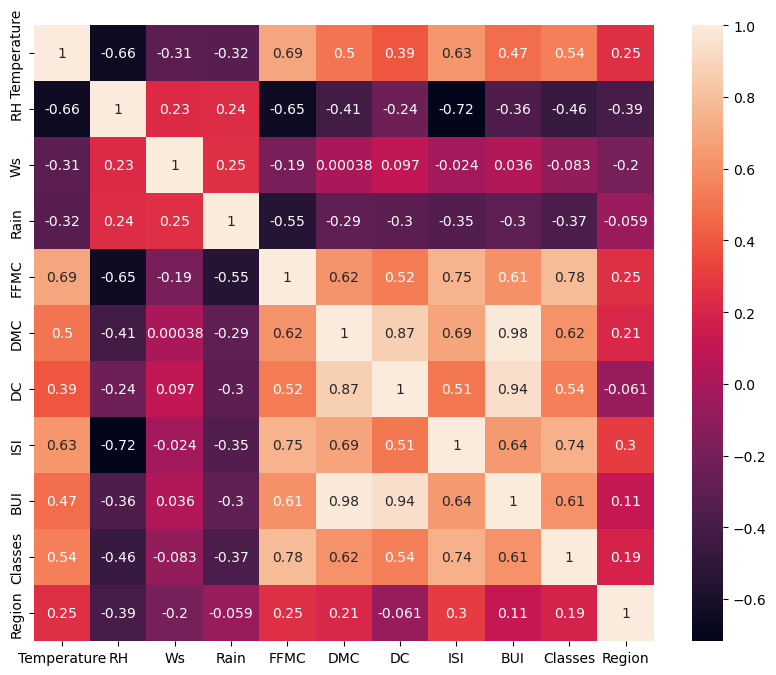

In [84]:
#check for multicollinearity
plt.figure(figsize=(10,8))
corr=x_train.corr()
sns.heatmap(corr, annot=True)
plt.show()

In [85]:
#defining function to check columns which are highly correlated
def correlation(dataset, threshold):
    col_corr=set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if(abs(corr_matrix.iloc[i, j])) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    
    return col_corr

In [86]:
corr_features = correlation(x_train, 0.85)
corr_features

{'BUI', 'DC'}

In [90]:
#drop the features
x_train.drop(corr_features, axis=1, inplace=True)
x_test.drop(corr_features, axis = 1, inplace=True)

In [94]:
x_test.shape

(61, 9)

In [95]:
x_train.shape

(182, 9)

## Feature Scaling Or Standardization

In [96]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
x_train_scaled = scalar.fit_transform(x_train)
x_test_scaled = scalar.transform(x_test)

In [97]:
x_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]])

## Box Plots To understand Effect Of Standard Scaler

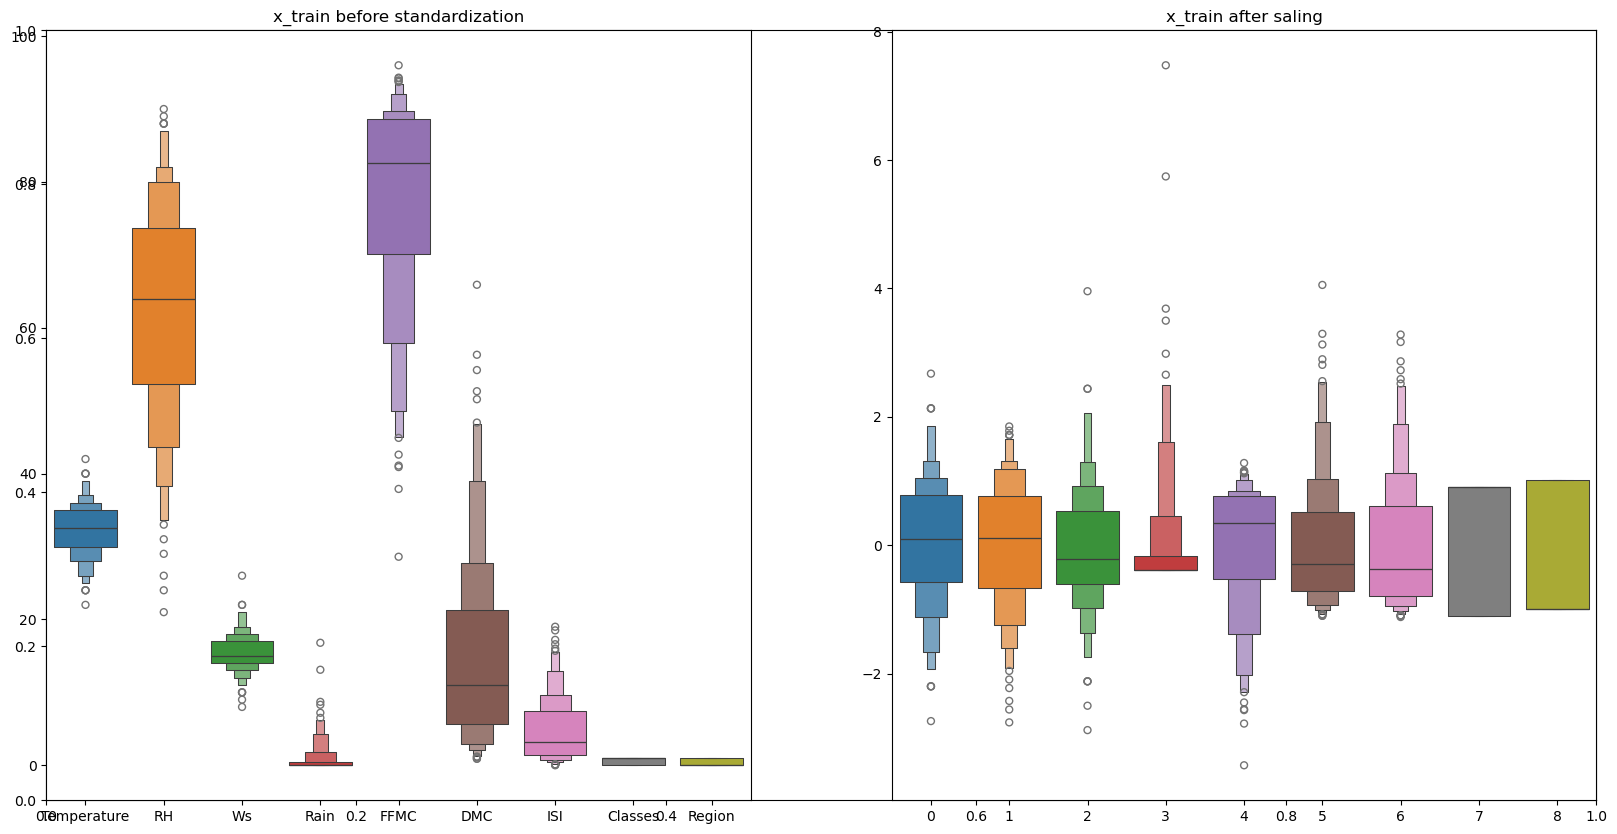

In [102]:
#checking for the outliers using outliers
plt.subplots(figsize=(20, 10))
plt.subplot(1,2,1)
sns.boxenplot(data=x_train)

plt.title('x_train before standardization')
plt.subplot(1,2,2)
sns.boxenplot(data=x_train_scaled)
plt.title('x_train after saling')
plt.show()

## Linear Regression Model

In [104]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

linreg = LinearRegression()

linreg.fit(x_train_scaled, y_train)

y_predicted = linreg.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_predicted)

score = r2_score(y_test, y_predicted)

print('Mean absolute error : ', mae)

print('R2 score', score)


Mean absolute error :  0.5468236465249976
R2 score 0.9847657384266951


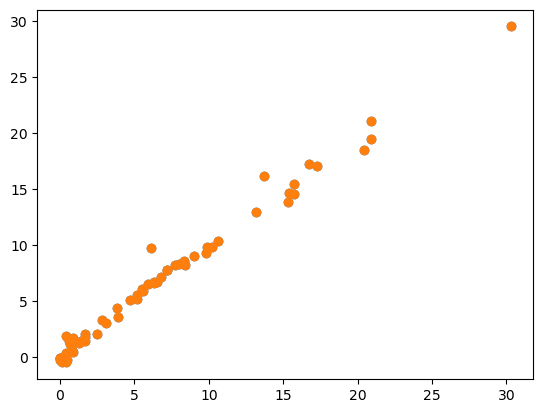

In [106]:
#scattter plot y_test vsy_predicted
plt.scatter(y_test, y_predicted)
plt.show()

## Lasso Regression

In [107]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score

lasso = Lasso()

lasso.fit(x_train_scaled, y_train)

y_predicted = lasso.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_predicted)

score = r2_score(y_test, y_predicted)

print('Mean absolute error : ', mae)

print('R2 score', score)


Mean absolute error :  1.1331759949144085
R2 score 0.9492020263112388


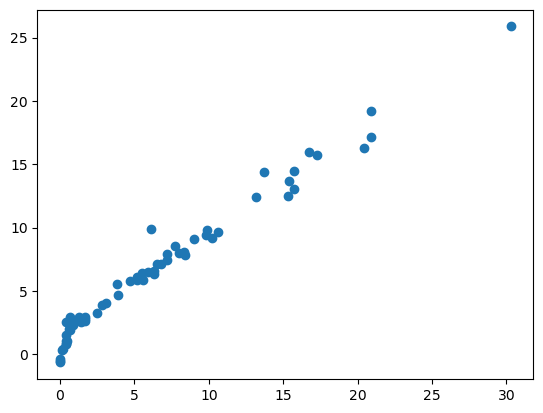

In [108]:
#scattter plot y_test vsy_predicted
plt.scatter(y_test, y_predicted)
plt.show()

### Ridge Regresssion Model

In [109]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

ridge = Ridge()

ridge.fit(x_train_scaled, y_train)

y_predicted = ridge.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_predicted)

score = r2_score(y_test, y_predicted)

print('Mean absolute error : ', mae)

print('R2 score', score)


Mean absolute error :  0.5642305340105693
R2 score 0.9842993364555513


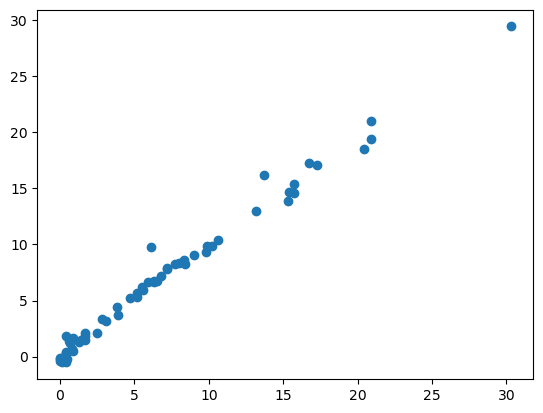

In [111]:
#plotting y_test and y_train
plt.scatter(y_test, y_predicted)
plt.show()

## Elasticnet Regresion Model

In [113]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score

elastic = ElasticNet()

elastic.fit(x_train_scaled, y_train)

y_predicted = elastic.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_predicted)

score = r2_score(y_test, y_predicted)

print('Mean absolute error : ', mae)

print('R2 score', score)


Mean absolute error :  1.8822353634896
R2 score 0.8753460589519703


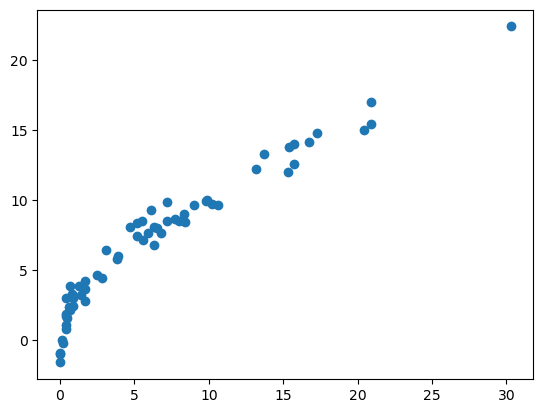

In [114]:
#sctter plot vs y_test and y_predicted
plt.scatter(y_test, y_predicted)
plt.show()

## Cross Validation (Hyperparameter training)

In [116]:
from sklearn.linear_model import LassoCV

lassoCv = LassoCV(cv=5)

lassoCv.fit(x_train_scaled, y_train)


LassoCV(cv=5)

In [117]:
lassoCv.alpha_

np.float64(0.05725391318234408)

In [120]:
lassoCv.mse_path_

array([[53.64536329, 65.39074075, 54.89628985, 77.90299066, 39.38236846],
       [46.99139716, 59.81506814, 49.29840831, 75.6645852 , 35.31758355],
       [41.14908917, 53.9178721 , 42.49594889, 68.35708298, 31.76996123],
       [36.05788169, 48.41773965, 36.66879347, 61.92819453, 28.67296816],
       [31.62067285, 42.76466229, 31.68391904, 56.26841266, 24.93183295],
       [27.75285367, 37.81922812, 27.42599138, 51.28216115, 21.56888645],
       [24.3807738 , 33.49107651, 23.7950306 , 45.25481907, 18.66094162],
       [21.44052804, 29.70161639, 20.70460191, 39.90418045, 16.14837778],
       [18.876308  , 26.38208059, 18.07969934, 35.23429953, 13.97821475],
       [16.63960395, 23.47341883, 15.85530749, 31.15712074, 12.10483403],
       [14.68819307, 20.92329068, 13.97555108, 27.59649208, 10.48862803],
       [12.98525144, 18.68636627, 12.39173305, 24.48611006,  9.09521221],
       [11.49893734, 16.72312788, 11.06186319, 21.7677198 ,  7.89445038],
       [10.2013182 , 14.9991189 ,  9.9

In [127]:
y_predicted = lassoCv.predict(x_test_scaled)

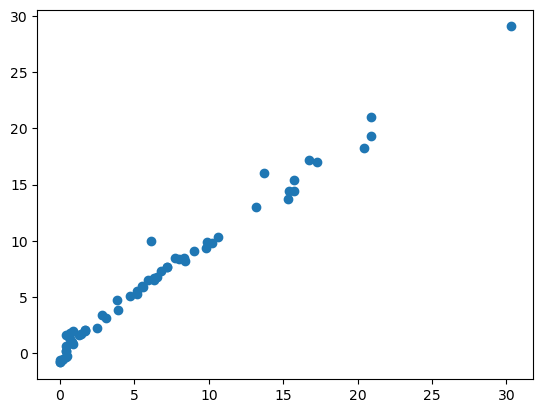

In [128]:
plt.scatter(y_test, y_predicted)
plt.show()

In [129]:
mae = mean_absolute_error(y_test, y_predicted)
score = r2_score(y_test, y_predicted)

print('Mean absolute error : ', mae)
print('R2 score : ', score)

Mean absolute error :  0.6199701158263431
R2 score :  0.9820946715928275
